In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import random
import numpy as np
from tqdm import tqdm
import collections
import gymnasium as gym
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import rl_utils

Define the ReplayBuffer

In [2]:
class ReplayBuffer:
    def __init__(self,capacity):
        self.buffer = collections.deque(maxlen=capacity)

    def add(self,state,action,reward,next_state,done):
        self.buffer.append((state,action,reward,next_state,done))

    def sample(self,batch_size):
        transitions = random.sample(self.buffer,batch_size)
        state,action,reward,next_state,done = zip(*transitions)
        return np.array(state), action, reward, np.array(next_state),done
    
    def size(self):
        return len(self.buffer)
    

Define the Q network(using nueral network to replace the Q tabular)

In [3]:
class Qnet(torch.nn.Module):
    def __init__(self,state_dim,hidden_dim,action_dim):
        super(Qnet,self).__init__()
        self.fc1 = torch.nn.Linear(state_dim,hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim,action_dim)

    def forward(self,x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)

Implementation of DQN

In [4]:
class DQN:
    def __init__(self,state_dim,hidden_dim,action_dim,learning_rate,gamma,
                 epsilon,target_update,device):
        
        self.action_dim = action_dim
        self.main_qnet = Qnet(state_dim,hidden_dim,action_dim).to(device)

        self.target_qnet = Qnet(state_dim,hidden_dim,action_dim).to(device)

        self.optimizer = torch.optim.Adam(self.main_qnet.parameters(),lr=learning_rate)

        self.gamma = gamma
        self.epsilon = epsilon
        self.target_update = target_update # Frequency of updating target network
        self.count = 0
        self.device = device

    def take_aciton(self,state):

        if np.random.random() < self.epsilon:
            action = np.random.randint(self.action_dim)
        else :
            # Wrap it with np.array , and add unsqueeze to increase the batch dimension.
            state = torch.tensor(np.array(state), dtype=torch.float32).unsqueeze(0).to(self.device)
            action = self.main_qnet(state).argmax().item()

        return action

    def update(self,transition_dict):
        states = torch.tensor(np.array(transition_dict['states']), dtype=torch.float32).to(self.device)
        actions = torch.tensor(np.array(transition_dict['actions']), dtype=torch.int64).view(-1, 1).to(self.device)
        rewards = torch.tensor(np.array(transition_dict['rewards']), dtype=torch.float32).view(-1, 1).to(self.device)
        next_states = torch.tensor(np.array(transition_dict['next_states']), dtype=torch.float32).to(self.device)
        dones = torch.tensor(np.array(transition_dict['dones']), dtype=torch.float32).view(-1, 1).to(self.device)
        
        q_values = self.main_qnet(states).gather(1,actions) # Take out Q-value of the action we taken from the Qnet

        max_next_q_values = self.target_qnet(next_states).max(1)[0].view(-1,1).detach()

        rewards = rewards.view(-1,1)
        dones = dones.view(-1,1)

        q_targets = rewards + self.gamma * max_next_q_values * (1-dones)

        dqn_loss = torch.mean(F.mse_loss(q_values,q_targets))
        self.optimizer.zero_grad()
        dqn_loss.backward()
        self.optimizer.step()

        if self.count % self.target_update==0 :
            self.target_qnet.load_state_dict(self.main_qnet.state_dict())
            # Update the target Qnet
        
        self.count += 1
        
        

Begin to train the model

In [ ]:
lr = 1e-3
num_episodes = 500
hidden_dim = 128
gamma = 0.98
epsilon = 0.01
target_update = 250
buffer_size = 10000
minimal_size = 500
batch_size = 64

if(torch.cuda.is_available()):
    device = 'cuda'
elif(torch.backends.mps.is_available()):
    device = 'mps'
else:
    device = 'cpu'


env_name = 'CartPole-v1'
env1 = gym.make(env_name)
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)


replay_buffer = ReplayBuffer(buffer_size)
state_dim = env1.observation_space.shape[0]
action_dim = env1.action_space.n
agent = DQN(state_dim, hidden_dim, action_dim, lr, gamma, epsilon,
            target_update, device)

return_list = []

for i in range(10):
    with tqdm(total=int(num_episodes / 10), desc='Iteration %d' % i) as pbar:
        for i_episode in range(int(num_episodes / 10)):
            episode_return = 0
            state,info = env1.reset(seed=0)
            done = False
            while not done:
                action = agent.take_aciton(state)
                next_state, reward, terminated, truncated, info = env1.step(action)
                done = terminated or truncated
                replay_buffer.add(state,action,reward,next_state,done)
                state = next_state
                episode_return += reward

                if replay_buffer.size() > minimal_size :

                    b_s, b_a, b_r, b_ns, b_d = replay_buffer.sample(batch_size)

                    transition_dict = {
                        'states': b_s,
                        'actions': b_a,
                        'next_states': b_ns,
                        'rewards': b_r,
                        'dones': b_d
                    }

                    agent.update(transition_dict)

            return_list.append(episode_return)
            if (i_episode + 1) % 10 == 0:
                pbar.set_postfix({
                    'episode':
                    '%d' % (num_episodes / 10 * i + i_episode + 1),
                    'return':
                    '%.3f' % np.mean(return_list[-10:])
                })
            pbar.update(1)
                



Iteration 9: 100%|██████████| 50/50 [00:04<00:00, 10.31it/s, episode=500, return=457.900]


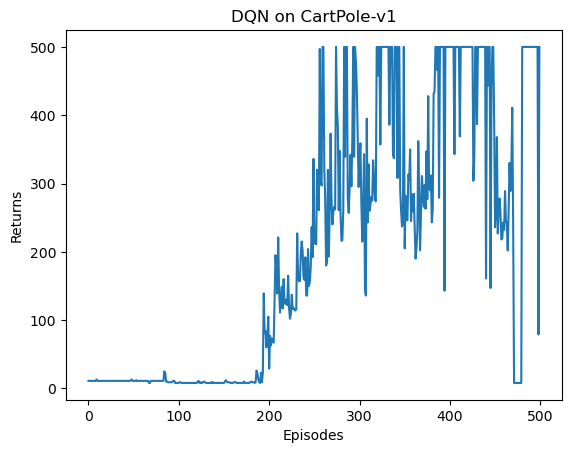

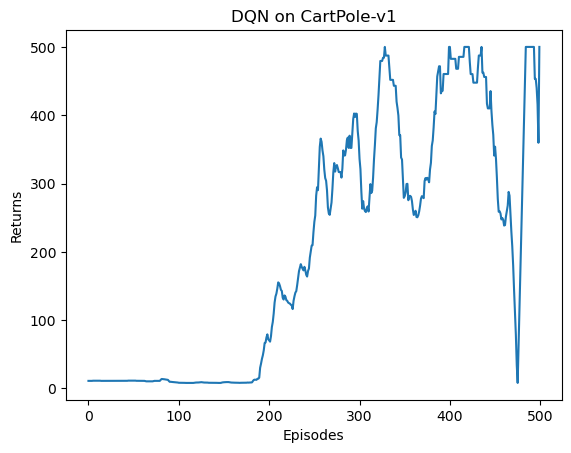

In [6]:
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('DQN on {}'.format(env_name))
plt.show()

mv_return = rl_utils.moving_average(return_list, 9)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('DQN on {}'.format(env_name))
plt.show()

It is very hard for classic DQN to find proper set of hyperparameters, can use dynamic epsilon to optimize, but the over estimation of the Qnet is hard to fix in current architecture

Dueling DQN

In [23]:
lr = 2e-3
num_episodes = 500
hidden_dim = 128
gamma = 0.98
epsilon = 0.01
target_update = 100
buffer_size = 10000
minimal_size = 100
batch_size = 64

env_name = 'Pendulum-v1'
env2 = gym.make(env_name)
state_dim = env2.observation_space.shape[0]
action_dim = 25  # The continuous motion is divided into 25 discrete motions.

def dis_to_con(discrete_action, env, action_dim):  # Functions that convert discrete actions back to continuous functions
    action_lowbound = env.action_space.low[0]  # minimum of continuous action
    action_upbound = env.action_space.high[0]  # maximum
    return action_lowbound + (discrete_action /
                              (action_dim - 1)) * (action_upbound -
                                                   action_lowbound)


def train_DQN(agent, env, num_episodes, replay_buffer, minimal_size,
              batch_size):
    return_list = []
    max_q_value_list = []
    max_q_value = 0
    for i in range(10):
        with tqdm(total=int(num_episodes / 10),
                  desc='Iteration %d' % i) as pbar:
            for i_episode in range(int(num_episodes / 10)):
                episode_return = 0
                state,info = env.reset()
                done = False
                while not done:
                    action = agent.take_action(state)
                    max_q_value = agent.max_q_value(
                        state) * 0.005 + max_q_value * 0.995  # smoothing
                    max_q_value_list.append(max_q_value)  # save the max_q for each state
                    action_continuous = dis_to_con(action, env,
                                                   agent.action_dim)
                    next_state, reward, terminated, truncated, info = env.step([action_continuous])
                    done = terminated or truncated
                    replay_buffer.add(state, action, reward, next_state, done)
                    state = next_state
                    episode_return += reward
                    if replay_buffer.size() > minimal_size:
                        b_s, b_a, b_r, b_ns, b_d = replay_buffer.sample(
                            batch_size)
                        transition_dict = {
                            'states': b_s,
                            'actions': b_a,
                            'next_states': b_ns,
                            'rewards': b_r,
                            'dones': b_d
                        }
                        agent.update(transition_dict)
                return_list.append(episode_return)
                if (i_episode + 1) % 10 == 0:
                    pbar.set_postfix({
                        'episode':
                        '%d' % (num_episodes / 10 * i + i_episode + 1),
                        'return':
                        '%.3f' % np.mean(return_list[-10:])
                    })
                pbar.update(1)
    return return_list, max_q_value_list

Iteration 9: 100%|██████████| 50/50 [00:05<00:00,  8.40it/s, episode=500, return=-99.626] 


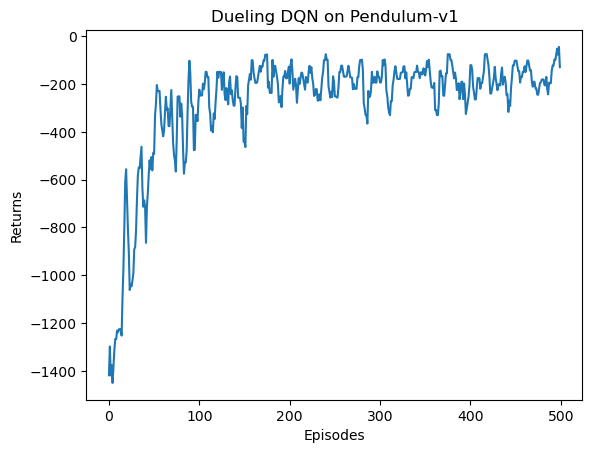

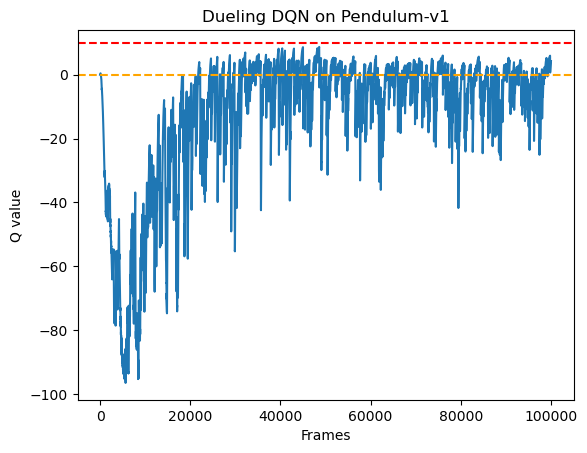

In [24]:
class VAnet(torch.nn.Module):
    ''' A and V network with one hidden layer '''
    def __init__(self, state_dim, hidden_dim, action_dim):
        super(VAnet, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)  # sharing network
        self.fc_A = torch.nn.Linear(hidden_dim, action_dim)
        self.fc_V = torch.nn.Linear(hidden_dim, 1)
        self.relu = torch.nn.ReLU()

    def forward(self, x):
        A = self.fc_A(self.relu(self.fc1(x)))
        V = self.fc_V(self.relu(self.fc1(x)))
        Q = V + A - A.mean(1).view(-1, 1)  # Q is calculate by V and A
        return Q


class DQN:
    ''' Double DQN and Dueling DQN '''
    def __init__(self,
                 state_dim,
                 hidden_dim,
                 action_dim,
                 learning_rate,
                 gamma,
                 epsilon,
                 target_update,
                 device,
                 dqn_type='VanillaDQN'):
        self.action_dim = action_dim
        if dqn_type == 'DuelingDQN':  
            self.q_net = VAnet(state_dim, hidden_dim,
                               self.action_dim).to(device)
            self.target_q_net = VAnet(state_dim, hidden_dim,
                                      self.action_dim).to(device)
        else:
            self.q_net = Qnet(state_dim, hidden_dim,
                              self.action_dim).to(device)
            self.target_q_net = Qnet(state_dim, hidden_dim,
                                     self.action_dim).to(device)
        self.optimizer = torch.optim.Adam(self.q_net.parameters(),
                                          lr=learning_rate)
        self.gamma = gamma
        self.epsilon = epsilon
        self.target_update = target_update
        self.count = 0
        self.dqn_type = dqn_type
        self.device = device

    def take_action(self, state):
        if np.random.random() < self.epsilon:
            action = np.random.randint(self.action_dim)
        else:
            state = torch.tensor(np.array(state), dtype=torch.float).unsqueeze(0).to(self.device)
            action = self.q_net(state).argmax().item()
        return action

    def max_q_value(self, state):
        state = torch.tensor(np.array(state), dtype=torch.float).unsqueeze(0).to(self.device)
        return self.q_net(state).max().item()

    def update(self, transition_dict):
        states = torch.tensor(transition_dict['states'],
                              dtype=torch.float).to(self.device)
        actions = torch.tensor(transition_dict['actions']).view(-1, 1).to(
            self.device)
        rewards = torch.tensor(transition_dict['rewards'],
                               dtype=torch.float).view(-1, 1).to(self.device)
        next_states = torch.tensor(transition_dict['next_states'],
                                   dtype=torch.float).to(self.device)
        dones = torch.tensor(transition_dict['dones'],
                             dtype=torch.float).view(-1, 1).to(self.device)

        q_values = self.q_net(states).gather(1, actions)
        if self.dqn_type == 'DoubleDQN':
            max_action = self.q_net(next_states).max(1)[1].view(-1, 1)
            max_next_q_values = self.target_q_net(next_states).gather(
                1, max_action)
        else:
            max_next_q_values = self.target_q_net(next_states).max(1)[0].view(
                -1, 1)
        q_targets = rewards + self.gamma * max_next_q_values * (1 - dones)
        dqn_loss = torch.mean(F.mse_loss(q_values, q_targets))
        self.optimizer.zero_grad()
        dqn_loss.backward()
        self.optimizer.step()

        if self.count % self.target_update == 0:
            self.target_q_net.load_state_dict(self.q_net.state_dict())
        self.count += 1


random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
replay_buffer = rl_utils.ReplayBuffer(buffer_size)
agent = DQN(state_dim, hidden_dim, action_dim, lr, gamma, epsilon,
            target_update, device, 'DuelingDQN')
return_list, max_q_value_list = train_DQN(agent, env2, num_episodes,
                                          replay_buffer, minimal_size,
                                          batch_size)

episodes_list = list(range(len(return_list)))
mv_return = rl_utils.moving_average(return_list, 5)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('Dueling DQN on {}'.format(env_name))
plt.show()

frames_list = list(range(len(max_q_value_list)))
plt.plot(frames_list, max_q_value_list)
plt.axhline(0, c='orange', ls='--')
plt.axhline(10, c='red', ls='--')
plt.xlabel('Frames')
plt.ylabel('Q value')
plt.title('Dueling DQN on {}'.format(env_name))
plt.show()